In [13]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Statsmodels
import statsmodels.api as sm

# Scikit-learn: data split & CV
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# Scikit-learn: preprocessing & pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn: models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# Scikit-learn: metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report
)

# Scikit-learn: calibration
from sklearn.calibration import CalibratedClassifierCV

In [4]:

# EDA from week2 Mod B
df_diabetes = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
df_ckd = pd.read_csv("Chronic_Kidney_Dsease_data.csv")
df_hypertension = pd.read_csv("hypertension_dataset.csv")
df_alzheimers = pd.read_csv("alzheimers_disease_data.csv")

# Generate basic summaries
diabetes_desc = df_diabetes.describe(include='all')
ckd_desc = df_ckd.describe(include='all')
hypertension_desc = df_hypertension.describe(include='all')
alzheimers_desc = df_alzheimers.describe(include='all')

# Check for duplicates
diabetes_duplicates = df_diabetes.duplicated().sum()
ckd_duplicates = df_ckd.duplicated().sum()
alzheimers_duplicates = df_alzheimers.duplicated().sum()
_duplicates = df_hypertension.duplicated().sum()
# Check for nulls
diabetes_nulls = df_diabetes.isnull().sum()
ckd_nulls = df_ckd.isnull().sum()
hypertension_nulls = df_hypertension.isnull().sum()
alzheimers__nulls = df_alzheimers.isnull().sum()

# Display descriptive summaries

print("\n===alzheimers-Summary ===")
print(ckd_desc)
# Return duplicates and total null values per dataset
print("\n=== Duplicates in alzheimers_duplicates Dataset ===")
print(f"alzheimers: {alzheimers_duplicates}")

# Return nulls
print("\n=== Total Null Values in alzheimers Dataset ===")
print(f"Diabealzheimerstes: {alzheimers__nulls.sum()}")


#Diabetes Dataset
#Duplicates: 24,206 rows — significant duplication, should be reviewed or removed
#Missing values: None
#Usability: Usable after deduplication

#Chronic Kidney Disease (CKD) Dataset
#Duplicates: None
#Missing values: None\
#Usability: Clean and ready for analysis

#Hypertension Dataset
#Duplicates: None
#Missing values: None
#Usability: Ready to use

# Steps to clean up Diabetes Dataset 
#Remove duplicates from the diabetes dataset: df_diabetes.drop_duplicates(inplace=True)
#Consider class balance checks (e.g., ratio of positive to negative labels)
#Identify categorical features and apply encoding (pd.get_dummies or OrdinalEncoder)
#Explore mode, median, and outliers for inconsistent data (e.g., age = 0)

#1 Remove Duplicates
df_diabetes.drop_duplicates(inplace=True)
#2 Handling any missing values
df_diabetes.fillna(df_diabetes.median(), inplace=True)  # For numeric columns
df_diabetes.fillna("Unknown", inplace=True)    # For categorical columns
#3Check for Inconsistencies
  #Negative ages or values outside expected range
  #Incorrect data types (e.g., numeric coded as string)
#4 Check for Class Imbalance

print(df_diabetes['Diabetes_binary'].value_counts(normalize=True))
print(df_hypertension['Hypertension'].value_counts(normalize=True))
#print(df_ckd['classification'].value_counts(normalize=True)) 

# Encode Categorical Variables
# One-hot encoding (for logistic regression, tree-based models)
df = pd.get_dummies(df_diabetes, drop_first=True)

# Or ordinal encoding if there is a natural order
#print("Arun")
#print(df_ckd.columns)
categorical_cols = df_ckd.select_dtypes(include=['object', 'category']).columns.tolist()
#print("Categorical columns:", categorical_cols)

from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df_ckd[['DoctorInCharge']] = encoder.fit_transform(df_ckd[['DoctorInCharge']])




===alzheimers-Summary ===
          PatientID          Age       Gender   Ethnicity  \
count   1659.000000  1659.000000  1659.000000  1659.00000   
unique          NaN          NaN          NaN         NaN   
top             NaN          NaN          NaN         NaN   
freq            NaN          NaN          NaN         NaN   
mean     830.000000    54.441230     0.515371     0.71308   
std      479.056364    20.549757     0.499914     1.00043   
min        1.000000    20.000000     0.000000     0.00000   
25%      415.500000    36.000000     0.000000     0.00000   
50%      830.000000    54.000000     1.000000     0.00000   
75%     1244.500000    72.000000     1.000000     1.00000   
max     1659.000000    90.000000     1.000000     3.00000   

        SocioeconomicStatus  EducationLevel          BMI      Smoking  \
count           1659.000000     1659.000000  1659.000000  1659.000000   
unique                  NaN             NaN          NaN          NaN   
top                  

Baseline ROC-AUC: 0.8246588660115968
Baseline PR-AUC: 0.9441318867479003
Baseline Brier: 0.16984753877835226
Best params: {'clf__C': 0.03, 'clf__l1_ratio': 1.0}
CV ROC-AUC: 0.7805741758241757
Test ROC-AUC (calibrated): 0.8179229887851117
Test PR-AUC  (calibrated): 0.9422026594572321
Test Brier   (calibrated): 0.1288562797537552
Chosen threshold: 0.7355363930736489
Confusion matrix (test):
 [[ 58  25]
 [ 80 267]]

Classification report (test):
               precision    recall  f1-score   support

           0      0.420     0.699     0.525        83
           1      0.914     0.769     0.836       347

    accuracy                          0.756       430
   macro avg      0.667     0.734     0.680       430
weighted avg      0.819     0.756     0.776       430



/home/codespace/.local/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


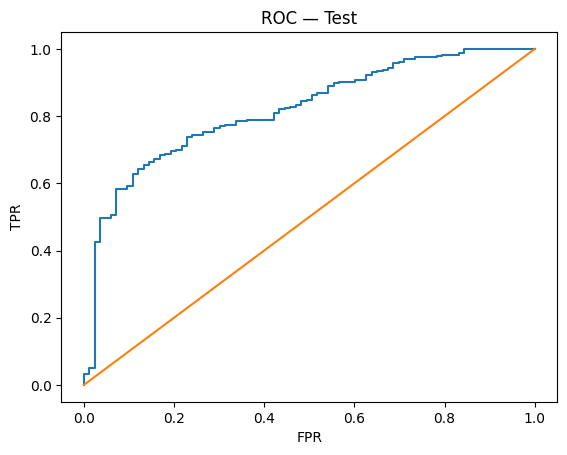

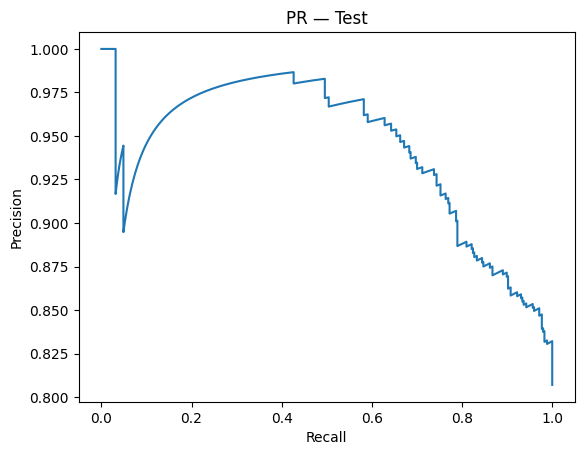

,feature,coef
31,num__Diagnosis,1.187746
22,num__FunctionalAssessment,0.130345
25,num__ADL,0.120821
18,num__CholesterolTotal,0.016201
0,num__Age,0.000000
1,num__Gender,0.000000
2,num__Ethnicity,0.000000
3,num__EducationLevel,0.000000
8,num__DietQuality,0.000000
9,num__SleepQuality,0.000000


,feature,coef
3,num__EducationLevel,0.000000
8,num__DietQuality,0.000000
9,num__SleepQuality,0.000000
10,num__FamilyHistoryAlzheimers,0.000000
12,num__Diabetes,0.000000
4,num__BMI,0.000000
5,num__Smoking,0.000000
6,num__AlcoholConsumption,0.000000
7,num__PhysicalActivity,0.000000
27,num__Disorientation,0.000000


In [15]:
df=df_alzheimers
TARGET = "MMSE"  
# --- Logistic Regression & Feature Scaling ----
# 2) Light cleanup
df = df.drop(columns=[c for c in ["PatientID","DoctorInCharge","ID","Id"] if c in df.columns])

# 3) Make a BINARY target from MMSE and DROP MMSE from features to avoid leakage
assert "MMSE" in df.columns, "MMSE not found in dataset."
df = df.dropna(subset=["MMSE"]).copy()
df["Impaired"] = (df["MMSE"] < 24).astype(int)     # 1 = impaired, 0 = not impaired

y = df["Impaired"].values                          # <-- KEEP binary target
X = df.drop(columns=["Impaired","MMSE"])           # <-- DROP MMSE to avoid leakage

# 4) Train/val/test split (stratified on the binary target)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)  # 60/20/20

# 5) Preprocessing
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_pre = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler())
])
categorical_pre = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer(
    [("num", numeric_pre, num_cols),
     ("cat", categorical_pre, cat_cols)],
    remainder="drop"
)

# 6) Baseline logistic (L2)
base_pipe = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(
        penalty="l2", solver="liblinear", max_iter=2000, class_weight="balanced"
    ))
])
base_pipe.fit(X_train, y_train)
p_test_base = base_pipe.predict_proba(X_test)[:, 1]
print("Baseline ROC-AUC:", roc_auc_score(y_test, p_test_base))
print("Baseline PR-AUC:",  average_precision_score(y_test, p_test_base))
print("Baseline Brier:",    brier_score_loss(y_test, p_test_base))

# 7) Elastic-net tuning
enet_pipe = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(
        penalty="elasticnet", solver="saga", max_iter=5000, class_weight="balanced"
    ))
])
param_grid = {
    "clf__C": [0.03, 0.1, 0.3, 1.0, 3.0],
    "clf__l1_ratio": [0.0, 0.2, 0.5, 0.8, 1.0]  # 0=ridge-like, 1=lasso-like
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(enet_pipe, param_grid=param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("CV ROC-AUC:", gs.best_score_)

# 8) Probability calibration
cal = CalibratedClassifierCV(gs.best_estimator_, method="sigmoid", cv="prefit")
cal.fit(X_val, y_val)  # calibrate on val split
p_test = cal.predict_proba(X_test)[:, 1]
print("Test ROC-AUC (calibrated):", roc_auc_score(y_test, p_test))
print("Test PR-AUC  (calibrated):", average_precision_score(y_test, p_test))
print("Test Brier   (calibrated):", brier_score_loss(y_test, p_test))

# 9) Threshold tuning (Youden’s J) on validation -> apply to test
p_val = cal.predict_proba(X_val)[:, 1]
fpr, tpr, thr = roc_curve(y_val, p_val)
best_thr = thr[np.argmax(tpr - fpr)]

yhat = (p_test >= best_thr).astype(int)
print("Chosen threshold:", best_thr)
print("Confusion matrix (test):\n", confusion_matrix(y_test, yhat))
print("\nClassification report (test):\n", classification_report(y_test, yhat, digits=3))

# 10) Curves
# ROC
fpr_t, tpr_t, _ = roc_curve(y_test, p_test)
plt.figure(); plt.plot(fpr_t, tpr_t); plt.plot([0,1],[0,1])
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — Test"); plt.show()
# PR
pr, rc, _ = precision_recall_curve(y_test, p_test)
plt.figure(); plt.plot(rc, pr)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR — Test"); plt.show()

# --- 11) Coefficients (robust feature-name extraction) ---

best_pipe = gs.best_estimator_          # fitted Pipeline(pre -> logistic)
clf      = best_pipe.named_steps["clf"]  # coefficients read from the tuned (pre-calibration) model
pre_fit  = best_pipe.named_steps["pre"]  # fitted ColumnTransformer

# Try the modern API first
try:
    feat_names = pre_fit.get_feature_names_out()
except Exception:
    # Manual fallback if your sklearn build doesn't support get_feature_names_out on ColumnTransformer
    cat_cols_used = pre_fit.transformers_[1][2] if len(pre_fit.transformers_) > 1 else []
    num_cols_used = pre_fit.transformers_[0][2] if len(pre_fit.transformers_) > 0 else []

    # OneHotEncoder feature names (if any categorical columns)
    try:
        ohe = pre_fit.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(cat_cols_used) if len(cat_cols_used) else np.array([])
    except Exception:
        cat_names = np.array(cat_cols_used, dtype=object)  # last-resort: raw names

    num_names = np.array(num_cols_used, dtype=object)
    feat_names = np.concatenate([num_names, cat_names])

# Coefficients are aligned with transformed features from the *fitted* preprocessor
coefs = clf.coef_.ravel()

coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs}) \
            .sort_values("coef", ascending=False)

display(coef_df.head(25))
display(coef_df.tail(25))